In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold, StratifiedKFold, GridSearchCV, learning_curve, LearningCurveDisplay
from sklearn.metrics import f1_score, make_scorer, confusion_matrix


from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import RFE, RFECV
from sklearn.metrics import accuracy_score, classification_report

from pathlib import Path

In [2]:
#BASE_DIR = Path(__file__).resolve().parent.parent
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "website_features.csv"

In [3]:
df = pd.read_csv(DATA_DIR)
df_processed = df.iloc[:, 1:20]

target_col = df_processed.columns[0]
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

X_cat = pd.get_dummies(X)
scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_cat)
X_scaled = X_cat

# pca = PCA(n_components=12)
# X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20, stratify=y)
target_names = ['benign' ,'gpt generated',  'malicious']


In [4]:
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20, stratify=y)

Classification Report CV:
               precision    recall  f1-score   support

       benign       0.92      0.87      0.89       639
gpt generated       0.54      0.62      0.58        99
    malicious       0.84      0.88      0.86       418

     accuracy                           0.85      1156
    macro avg       0.77      0.79      0.78      1156
 weighted avg       0.86      0.85      0.85      1156

Average Cross-Validation Accuracy: 0.8495 with std: 0.0000

Confusion Matrix on CV Predictions:


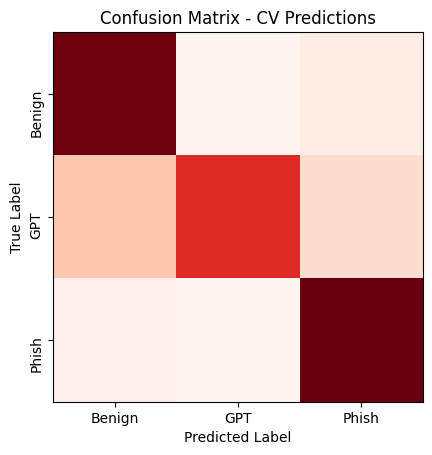


--- Test Set Performance ---
Accuracy: 0.8893

Classification Report:
               precision    recall  f1-score   support

       benign       0.95      0.88      0.92       159
gpt generated       0.67      0.80      0.73        25
    malicious       0.87      0.92      0.89       105

     accuracy                           0.89       289
    macro avg       0.83      0.87      0.85       289
 weighted avg       0.90      0.89      0.89       289



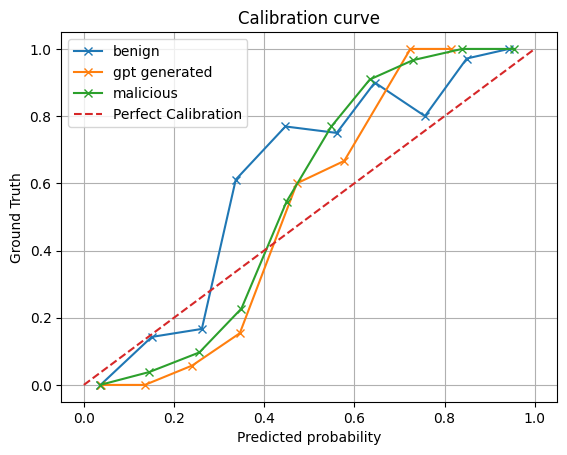

In [5]:
# ========================= Running Model =========================

rfc = RandomForestClassifier(n_estimators=50, random_state=20, max_depth=10, class_weight='balanced', min_samples_split=2, max_features='sqrt', verbose=False)
model1 = rfc.fit(X_train, y_train)
predictions = model1.predict(X_test)


kf = KFold(n_splits=5, shuffle=True, random_state=None)
cv_scores = cross_val_score(model1, X_train, y_train, cv=kf).mean()
cv_predict = cross_val_predict(model1, X_train, y_train, cv=kf)


# GScv = GridSearchCV(estimator=RandomForestClassifier(random_state=20, class_weight='balanced'),
#                     param_grid={
#                         'n_estimators': [10, 25, 50, 100, 200],
#                         'max_depth': [10, 20, 30, None],
#                         'min_samples_split': [2, 5, 10, 20, 50, 100],
#                         'max_features': ['sqrt', 'log2', None]
#                     },
#                     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=20),
#                     n_jobs=-1,
#                     scoring='f1_weighted')

# GScv.fit(X_train, y_train)
# print(f'Best Hyper Parameters: {GScv.best_params_} and best score: {GScv.best_score_:.4f}')

print('Classification Report CV:')
print(f'{classification_report(y_train, cv_predict, target_names=target_names)}')
print(f"Average Cross-Validation Accuracy: {cv_scores.mean():.4f} with std: {cv_scores.std():.4f}")

from matplotlib import pyplot as plt

print("\nConfusion Matrix on CV Predictions:")
cm = confusion_matrix(y_train, cv_predict, labels=[0,1,2], normalize='true')
fig, ax = plt.subplots()
plt.title('Confusion Matrix - CV Predictions')
im = ax.imshow(cm, cmap='Reds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
ax.set_xticks([0,1,2])
ax.set_yticks([0,1,2])
ax.set_xticklabels(['Benign', 'GPT', 'Phish'])
ax.set_yticklabels(['Benign', 'GPT', 'Phish'], rotation=90)
plt.show()


print("\n--- Test Set Performance ---")
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=target_names))



from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

predict_probas = model1.predict_proba(X_test)
# calibration curve
for i, name in enumerate(target_names):
    prob_true, prob_pred = calibration_curve((y_test == i).astype(int), predict_probas[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='x', label=name)

plt.plot([0,1], linestyle='--', label='Perfect Calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Ground Truth')
plt.title('Calibration curve')
plt.legend()
plt.grid()
plt.show()




NOTE: Using macro-f1 to give equal weight to the GPT-generated class.

# Results Log

| Run  | Model(s)                              | Hyperparameters                                                | Handling Imabalance | Macro F1 | Note         |
| ---- | ------------------------------------- | -------------------------------------------------------------- | ------------------- | -------- | ------------ |
| RF1  | RF                                    | Default, estimator=50                                          | Balanced Weights    | 0.83     | None         |
| RF2  | RF                                    | estimator=50, depth=10, max_features=sqrt, min_samples_split=2 | Balanced Weights    | 0.85     | Grid Search  |
| RF3  | EasyEnsemble                          | estimator=50, depth=10                                         | Undersampling       | 0.72     | uncalibrated |
| STK1 | RF, SVC, KNN, Meta=LogisticRegression | See Code (viability.py)                                        | Balanced Weights    | 0.79     | None         |


# Ablation Study

This section will involve removing specific features, retrain and rerun the model. If no change or imporovement is seen we can infer the feature is redundant or adds noise.


In [6]:
# X_encoded = X.copy()
# for col in X_encoded.select_dtypes(include='object').columns:
#     X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

# # Fit RFE on encoded data
# model = RandomForestClassifier(
#     n_estimators=50, random_state=20, max_depth=10,
#     class_weight='balanced', min_samples_split=2,
#     max_features='sqrt'
# )
# rfe = RFECV(model, cv=5, scoring='f1_macro')
# rfe.fit(X_encoded, y)

# # Recover selected feature names from the ORIGINAL X
# selected_features = X.columns[rfe.support_].tolist()
# print("Selected features:", selected_features)
# print(len(selected_features))
# X_selected = X[selected_features]  # original strings intact for your pipeline

feautres = ['link_count', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullHyperlinks', 'nb_extCSS', 'login_form',
                    'favicon','presence_of_links_in_tags','email_submission_forms', 'internal_media_count', 'external_media_count',
                    'sfh', 'nb_iframes', 'nb_popup_window','onmouseover', 'rcd', 'empty_title', 'page_depth'] 


cat_cols = X.select_dtypes(include='object').columns
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = X.copy()
X_encoded[cat_cols] = oe.fit_transform(X[cat_cols])

#rfe = RFECV(estimator=RandomForestClassifier(), cv=5, scoring='f1_macro')
rfe = RFECV(estimator=rfc, cv=5, scoring='f1_macro')
rfe.fit(X_encoded, y)
#print(rfe.cv_results_)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,RandomForestC...verbose=False)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'f1_macro'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10


Kept feautres: ['link_count' 'ratio_intHyperlinks' 'ratio_extHyperlinks'
 'ratio_nullHyperlinks' 'nb_extCSS' 'login_form' 'favicon'
 'presence_of_links_in_tags' 'internal_media_count' 'external_media_count'
 'sfh' 'nb_iframes' 'empty_title' 'page_depth'] 

Excluded features: ['email_submission_forms' 'nb_popup_window' 'onmouseover' 'rcd']


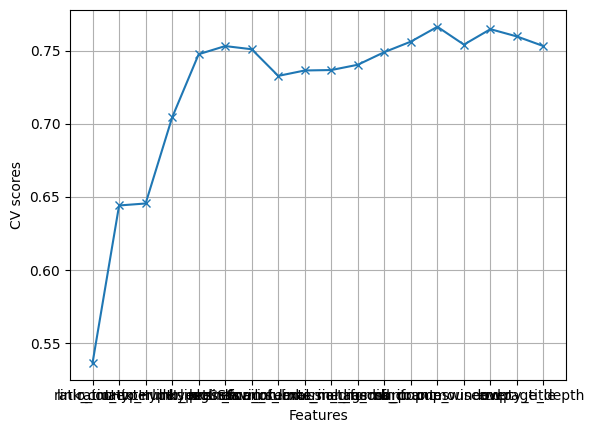

In [ ]:
feautres = np.array(feautres)

mask = rfe.support_
#print(mask)
negative_mask = ~mask

print(f'Kept feautres: {feautres[mask]} \n')
print(f'Excluded features: {feautres[negative_mask]}')

#print(f'Best CV score: {rfe.cv_results_['mean_test_score']}')

plt.figure()
plt.plot(feautres, rfe.cv_results_['mean_test_score'], 'x-')
plt.xlabel("Features")
plt.ylabel("CV scores")
plt.grid()
plt.show()


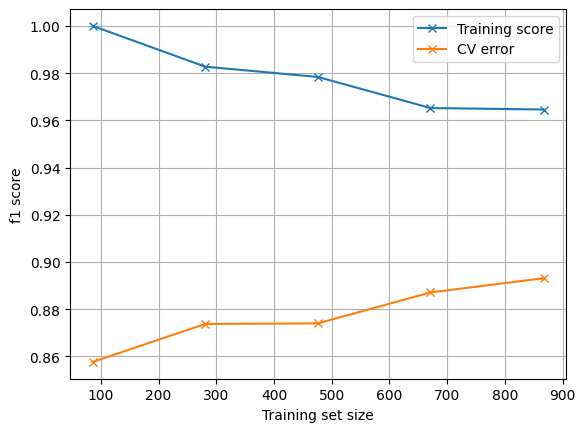

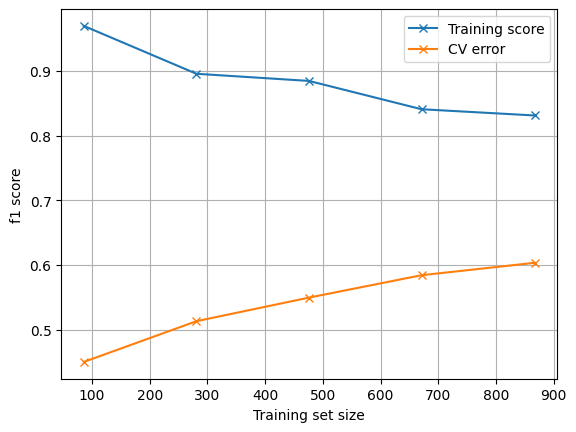

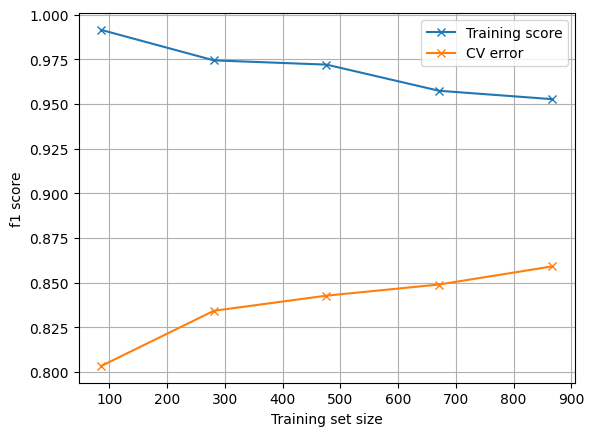

In [8]:
'''
Learning curve
checking if worth collecting more data for GPT generated class - or at least capture general trend
'''

def learning_analysis(model, X, y, class_name):
    scorer = make_scorer(f1_score, average='weighted', labels=[class_name])

    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=4, scoring=scorer, shuffle=True, random_state=12, )
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, 'x-', label='Training score')
    plt.plot(train_sizes, test_mean,'x-', label='CV error')
    plt.xlabel("Training set size")
    plt.ylabel("f1 score")
    plt.legend()
    plt.grid()
    plt.show()

learning_analysis(model1, X_train, y_train, 0)
learning_analysis(model1, X_train, y_train, 1)
learning_analysis(model1, X_train, y_train, 2)

    